# Example 1b: Observations and sensors

WindGym environments hand your agent a flat vector of numbers in `[-1, 1]`. Which numbers, in what order, and what they mean is decided entirely by the `mes_level` and `*_mes` sections of the environment config.

This notebook will go though these details: 

Everything here runs on the fast steady-state **pywake backend** with no turbulence box, so every cell executes in seconds. See *Example 1 Make environment* for the full dynamic setup.


## 0. The measurement pipeline

Between "the simulator knows the wind" and "the agent sees an observation" sits a small pipeline:

```text
config (mes_level, *_mes)      your dict / YAML file / YAML string
        |  _apply_config
        v
FarmMes                        one TurbMes per turbine + one aggregate "farm" TurbMes
        |  every env step: add_measurements(ws, wd, yaw, power)
        v
Mes ring buffers               one deque per channel (ws, wd, yaw, ...) per turbine
        |  _get_obs(): get_measurements(scaled=True)
        v
observation vector             scaled to [-1, 1], clipped, float32
```

- Each **`Mes`** is a ring buffer (`collections.deque`) holding the last `history_length` per-env-step means. When asked to report, it returns the optional *current* value plus `history_N` *window means*.
- **`TurbMes`** bundles one `Mes` per channel for a single turbine (wind speed, wind direction, yaw, derate, power) plus a turbulence-intensity estimate.
- **`FarmMes`** owns one `TurbMes` per turbine, and an extra aggregate `TurbMes` fed with the farm mean (ws, wd) or farm total (power).
- `WindFarmEnv._get_obs()` concatenates everything scaled to `[-1, 1]` and clips.

The sensor config is essentially the constructor arguments of these classes. The `config` argument itself can be a dict (used throughout this notebook), a path to a YAML file, or a YAML string — `WindFarmEnv` normalizes all three to the same dict.


In [1]:
import copy

import numpy as np
import matplotlib.pyplot as plt
from py_wake.examples.data.hornsrev1 import V80

from WindGym import WindFarmEnv

# A small teaching config. Only the sensor sections vary in this notebook;
# farm/wind/reward stay fixed. The wind is frozen (min == max) so every
# reset sees the same 10 m/s westerly inflow at 6 % TI.
BASE_CFG = {
    "yaw_init": "Zeros",
    "BaseController": "Local",
    "ActionMethod": "wind",  # action = target yaw offset
    "farm": {"yaw_min": -30, "yaw_max": 30},  # also the yaw *scaling* bounds (Part 3)
    "wind": {
        "ws_min": 10.0, "ws_max": 10.0,
        "wd_min": 270.0, "wd_max": 270.0,
        "TI_min": 0.06, "TI_max": 0.06,
    },
    "act_pen": {"action_penalty": 0.0, "action_penalty_type": "change"},
    "power_def": {"Power_reward": "Power_avg", "Power_avg": 5, "Power_scaling": 1.0},

    # --- which measurement blocks exist at all -------------------------
    "mes_level": {
        "turb_ws": True,      # per-turbine wind speed block
        "turb_wd": True,      # per-turbine wind direction block
        "turb_TI": False,     # per-turbine turbulence intensity (always size 1)
        "turb_power": False,  # per-turbine power block
        "farm_ws": True,      # farm-average wind speed block
        "farm_wd": False,     # farm-average wind direction block
        "farm_TI": False,     # farm-average TI (always size 1)
        "farm_power": False,  # farm-total power block
    },

    # --- per-channel sensor shape --------------------------------------
    # ws: the current value AND 3 rolling-window means over a 20-step history
    "ws_mes": {
        "ws_current": True,
        "ws_rolling_mean": True,
        "ws_history_N": 3,        # how many window means to report
        "ws_history_length": 20,  # ring-buffer length (env steps)
        "ws_window_length": 5,    # width of each averaging window (env steps)
    },
    # wd, yaw: current value only
    "wd_mes": {
        "wd_current": True, "wd_rolling_mean": False,
        "wd_history_N": 1, "wd_history_length": 20, "wd_window_length": 5,
    },
    "yaw_mes": {
        "yaw_current": True, "yaw_rolling_mean": False,
        "yaw_history_N": 1, "yaw_history_length": 20, "yaw_window_length": 5,
    },
    # power: nothing (turb_power/farm_power are off anyway)
    "power_mes": {
        "power_current": False, "power_rolling_mean": False,
        "power_history_N": 1, "power_history_length": 20, "power_window_length": 5,
    },
}


def make_env(cfg, n_turb=2, **kwargs):
    """A small row of V80s on the fast steady-state pywake backend."""
    d = V80().diameter()
    defaults = dict(
        turbine=V80(),
        x_pos=np.arange(n_turb) * 5.0 * d,  # 5D spacing; wind flows T0 -> T1 -> ...
        y_pos=np.zeros(n_turb),
        config=cfg,
        backend="pywake",   # steady-state flow model: cheap to build and step
        turbtype="None",    # no turbulence box
        reset_init=False,   # don't reset during __init__; spaces exist anyway
        n_passthrough=1,    # short episodes
        fill_window=False,  # one measurement pre-step at reset (see Part 4)
    )
    defaults.update(kwargs)
    return WindFarmEnv(**defaults)


## 1. Config anatomy

Two groups of keys control the observation vector.

**`mes_level` — which blocks exist** (all 8 keys are required):

| Key | Meaning |
|---|---|
| `turb_ws` | each turbine observes its local wind speed |
| `turb_wd` | each turbine observes its local wind direction |
| `turb_TI` | each turbine observes its local turbulence intensity (always exactly 1 slot) |
| `turb_power` | each turbine observes its own power |
| `farm_ws` | one shared block with the farm-**mean** wind speed |
| `farm_wd` | one shared block with the farm-**mean** (circular) wind direction |
| `farm_TI` | one shared slot with the farm-mean TI |
| `farm_power` | one shared block with the farm-**total** power |

**`ws_mes` / `wd_mes` / `yaw_mes` / `power_mes` — the shape of each channel** (5 keys each, shown for `ws`):

| Key | Meaning |
|---|---|
| `ws_current` | report the latest per-env-step mean |
| `ws_rolling_mean` | additionally report window means over the history |
| `ws_history_N` | how many window means to report |
| `ws_history_length` | ring-buffer capacity, in env steps |
| `ws_window_length` | width of each averaging window, in env steps |

Two rules people miss:

1. **Yaw is always observed per turbine.** There is no `turb_yaw` switch in `mes_level` — whenever `yaw_current`/`yaw_rolling_mean` are on, every turbine reports its yaw.
2. **A channel is only active if both its `*_mes` flags and its `mes_level` switch are on.** `turb_power: True` with both `power_*` flags off contributes nothing, and vice versa. (Exception: TI has no `*_mes` section — its `mes_level` switch alone adds one slot.)


In [2]:
env = make_env(BASE_CFG)

print("observation_space:", env.observation_space)
print("obs_var (total observed variables):", env.obs_var)
print("action_space:", env.action_space)


observation_space: Box(-1.0, 1.0, (16,), float32)
obs_var (total observed variables): 16
action_space: Box(-1.0, 1.0, (2,), float32)


## 2. Predicting the observation size

Each active channel contributes

```text
size(channel) = current + rolling_mean * history_N
```

slots (booleans count as 0/1). Then

```text
per_turbine = turb_ws*size(ws) + turb_wd*size(wd) + size(yaw) + turb_TI + turb_power*size(power)
farm_block  = farm_ws*size(ws) + farm_wd*size(wd) + farm_TI + farm_power*size(power)
total       = n_turb * per_turbine + farm_block
```

Walking `BASE_CFG` with 2 turbines by hand:

| Channel | Active? | Size |
|---|---|---|
| ws (per turbine) | `turb_ws` ✓ | 1 + 3 = 4 |
| wd (per turbine) | `turb_wd` ✓ | 1 |
| yaw (always) | ✓ | 1 |
| TI, power | off | 0 |
| **per turbine** | | **6** |
| farm ws | `farm_ws` ✓ | 1 + 3 = 4 |
| **total** | 2 × 6 + 4 | **16** |

The next cell turns the formula into a function and checks it against the real `observation_space` for a handful of config variants. The `assert`s double as a regression test of the formula.


In [3]:
def expected_obs_size(cfg, n_turb):
    """Predict the observation size from the config alone."""
    lvl = cfg["mes_level"]

    def size(prefix):
        m = cfg[f"{prefix}_mes"]
        return int(m[f"{prefix}_current"]) + int(m[f"{prefix}_rolling_mean"]) * m[f"{prefix}_history_N"]

    per_turbine = (
        lvl["turb_ws"] * size("ws")
        + lvl["turb_wd"] * size("wd")
        + size("yaw")                      # yaw: always observed per turbine
        + lvl["turb_TI"]                   # TI: always exactly 1 slot when on
        + lvl["turb_power"] * size("power")
    )
    farm_block = (
        lvl["farm_ws"] * size("ws")
        + lvl["farm_wd"] * size("wd")
        + lvl["farm_TI"]
        + lvl["farm_power"] * size("power")
    )
    return n_turb * per_turbine + farm_block


def variant(name, **changes):
    """Deep-copy BASE_CFG and update whole sections, e.g. mes_level={"farm_ws": False}."""
    cfg = copy.deepcopy(BASE_CFG)
    for section, updates in changes.items():
        cfg[section].update(updates)
    return name, cfg


variants = [
    ("BASE_CFG", copy.deepcopy(BASE_CFG)),
    variant("no farm block", mes_level={"farm_ws": False}),
    variant("+ turbine TI", mes_level={"turb_TI": True}),
    variant("+ turbine power (current)",
            mes_level={"turb_power": True}, power_mes={"power_current": True}),
    variant("ws_history_N = 5", ws_mes={"ws_history_N": 5}),
    variant("+ wd rolling mean (N=3)",
            wd_mes={"wd_rolling_mean": True, "wd_history_N": 3}),
]

print(f"{'variant':<28} {'predicted':>9} {'actual':>7}")
for name, cfg in variants:
    e = make_env(cfg, n_turb=2)
    predicted = expected_obs_size(cfg, n_turb=2)
    actual = e.observation_space.shape[0]
    assert predicted == actual, f"{name}: predicted {predicted}, got {actual}"
    print(f"{name:<28} {predicted:>9} {actual:>7}")

print("\nAll predictions match the real observation spaces.")


variant                      predicted  actual
BASE_CFG                            16      16
no farm block                       12      12
+ turbine TI                        18      18
+ turbine power (current)           18      18
ws_history_N = 5                    22      22
+ wd rolling mean (N=3)             22      22

All predictions match the real observation spaces.


## 3. Decoding the vector

The ordering rules (fixed by `FarmMes.get_measurements` / `TurbMes.get_measurements`):

1. **Turbine blocks first** — turbine 0, then turbine 1, … The **farm block comes last**.
2. Within a turbine block the channel order is: probes (if any), **ws, wd, yaw, derate, TI, power**.
3. Within a channel: the **current** value first, then window means **newest → oldest** (`hist_0` is the most recent window).
4. The farm block orders its channels **ws, wd, TI, power**.

You could work out indices by hand from these rules — but the env can do it for you. `MeasurementManager` (from `WindGym.core`) inspects an environment and builds one `MeasurementSpec` per observation slot: a name, its index range, and its physical scaling bounds. It is also the entry point to the measurement-noise system (see the noise-and-uncertainty docs); here we use it purely as an index map.

In [4]:
from WindGym.core import MeasurementManager

mm = MeasurementManager(env)

print(f"{'index':>5}   {'name':<22} physical range")
for spec in mm.specs:
    lo, hi = spec.index_range
    print(f"{lo:>5}   {spec.name:<22} [{spec.min_val}, {spec.max_val}]")


index   name                   physical range
    0   turb_0/ws_current      [0.0, 30.0]
    1   turb_0/ws_hist_0       [0.0, 30.0]
    2   turb_0/ws_hist_1       [0.0, 30.0]
    3   turb_0/ws_hist_2       [0.0, 30.0]
    4   turb_0/wd_current      [0, 360]
    5   turb_0/yaw_current     [-30, 30]
    6   turb_1/ws_current      [0.0, 30.0]
    7   turb_1/ws_hist_0       [0.0, 30.0]
    8   turb_1/ws_hist_1       [0.0, 30.0]
    9   turb_1/ws_hist_2       [0.0, 30.0]
   10   turb_1/wd_current      [0, 360]
   11   turb_1/yaw_current     [-30, 30]
   12   farm/ws_current        [0.0, 30.0]
   13   farm/ws_hist_0         [0.0, 30.0]
   14   farm/ws_hist_1         [0.0, 30.0]
   15   farm/ws_hist_2         [0.0, 30.0]


### Scaling

Every slot is scaled from its physical range `[min, max]` to `[-1, 1]`:

```text
scaled = 2 * (x - min) / (max - min) - 1        # TurbMes._scale_val
x      = (scaled + 1) / 2 * (max - min) + min   # inverse
```

and the final vector is clipped to `[-1, 1]`, so out-of-range physical values saturate rather than leak out.

Where the bounds come from:

| Channel | Bounds | Default | Set by |
|---|---|---|---|
| ws | `[ws_scaling_min, ws_scaling_max]` | `[0, 30]` m/s | `WindFarmEnv` constructor kwargs |
| wd | `[wd_scaling_min, wd_scaling_max]` | `[0, 360]`° | constructor kwargs |
| TI | `[ti_scaling_min, ti_scaling_max]` | `[0, 1]` | constructor kwargs |
| yaw | `[yaw_min, yaw_max]` | — | **the config's `farm` section** |
| power | `[0, power_max]`; farm block `[0, n_turb * power_max]` | turbine rated power | the turbine object |

The yaw row is the gotcha: `yaw_scaling_min/max` constructor kwargs exist, but `_apply_config` overwrites them with `farm.yaw_min` / `farm.yaw_max` from the config. With `BASE_CFG` a scaled yaw of `0.5` means `+15°`, not `+22.5°`.

Let's reset the env and decode the whole vector — once by hand with the inverse formula, and once with the manager's helper. The same physical values also show up (unscaled) in the `info` dict, so you can confirm the two views agree. Expect turbine 0 near the free-stream 10 m/s and turbine 1 lower: it sits in T0's wake.


In [5]:
obs, info = env.reset(seed=0)


def unscale(scaled, lo, hi):
    return (scaled + 1) / 2 * (hi - lo) + lo


physical = mm._get_physical_values_from_obs_for_logging(obs)

print(f"{'index':>5}   {'name':<22} {'scaled':>8}   {'by hand':>9}   {'manager':>9}")
for spec in mm.specs:
    i = spec.index_range[0]
    by_hand = unscale(obs[i], spec.min_val, spec.max_val)
    print(f"{i:>5}   {spec.name:<22} {obs[i]:>8.3f}   {by_hand:>9.3f}   {physical[spec.name]:>9.3f}")

# The same physical numbers are also reported (unscaled) in `info`:
print("\ninfo['Wind speed at turbines measured']:", info["Wind speed at turbines measured"])
print("info['Wind speed at farm measured']    :", info["Wind speed at farm measured"])
print("info['yaw angles measured']            :", info["yaw angles measured"])


index   name                     scaled     by hand     manager
    0   turb_0/ws_current        -0.333      10.000      10.000
    1   turb_0/ws_hist_0         -0.333      10.000      10.000
    2   turb_0/ws_hist_1         -0.333      10.000      10.000
    3   turb_0/ws_hist_2         -0.333      10.000      10.000
    4   turb_0/wd_current         0.500     270.000     270.000
    5   turb_0/yaw_current        0.000       0.000       0.000
    6   turb_1/ws_current        -0.673       4.899       4.899
    7   turb_1/ws_hist_0         -0.673       4.899       4.899
    8   turb_1/ws_hist_1         -0.673       4.899       4.899
    9   turb_1/ws_hist_2         -0.673       4.899       4.899
   10   turb_1/wd_current         0.500     270.000     270.000
   11   turb_1/yaw_current        0.000       0.000       0.000
   12   farm/ws_current          -0.503       7.449       7.449
   13   farm/ws_hist_0           -0.503       7.449       7.449
   14   farm/ws_hist_1           -0.503 

### Why the bounds matter

The agent only ever sees the scaled numbers. The same physical wind maps to a completely different observation if you change the scaling bounds — and values outside the bounds silently clip to ±1.

Below we rebuild the identical environment with `ws_scaling_max=12.0` instead of the default 30. The same 10 m/s inflow now lands at scaled ≈ +0.67, near the top of the range; anything above 12 m/s would saturate at 1.0.

The practical rule: **scaling bounds are part of the model interface**. A policy trained with `ws_scaling_max=30` reads `0.67` as 25 m/s; run it against an env scaled to 12 m/s and every wind-speed input it sees is wrong — with no error raised anywhere. Keep the scaling kwargs (and the config's yaw limits) identical between training and evaluation/deployment.


In [6]:
env_narrow = make_env(BASE_CFG, ws_scaling_max=12.0)
obs_narrow, _ = env_narrow.reset(seed=0)
mm_narrow = MeasurementManager(env_narrow)

for label, o, spec in [
    ("default bounds [0, 30]", obs, mm.specs[0]),          # turb_0/ws_current
    ("narrow bounds  [0, 12]", obs_narrow, mm_narrow.specs[0]),
]:
    i = spec.index_range[0]
    print(f"{label}: scaled = {o[i]:+.3f} -> physical = "
          f"{unscale(o[i], spec.min_val, spec.max_val):.2f} m/s")


default bounds [0, 30]: scaled = -0.333 -> physical = 10.00 m/s
narrow bounds  [0, 12]: scaled = +0.667 -> physical = 10.00 m/s


## 4. History and rolling means

One `Mes` object per channel does all the buffering. Every env step, the mean of that step's simulation sub-samples is appended to a deque of length `history_length`. When the observation is built, the `Mes` reports:

- **`current`** — the newest entry (last env step's mean), if `*_current` is on;
- **`hist_0 … hist_{N-1}`** — `history_N` means over windows of `window_length` entries, if `*_rolling_mean` is on. `hist_0` averages the newest window, `hist_{N-1}` the oldest, and the rest are spaced evenly in between. While the buffer is still filling, the windows shrink or overlap gracefully instead of erroring.

So `history_N=3, history_length=20, window_length=5` means: *three 5-step averages spread across the last 20 steps* — a cheap fixed-size summary of the recent past.

For wind direction the same machinery runs with **circular means** (`circular=True`), so a buffer holding `[359°, 1°]` averages to 0°, not 180°.

The next cell drives a single `Mes` directly — no environment — with a noisy sine, so you can see exactly what each reported value tracks.


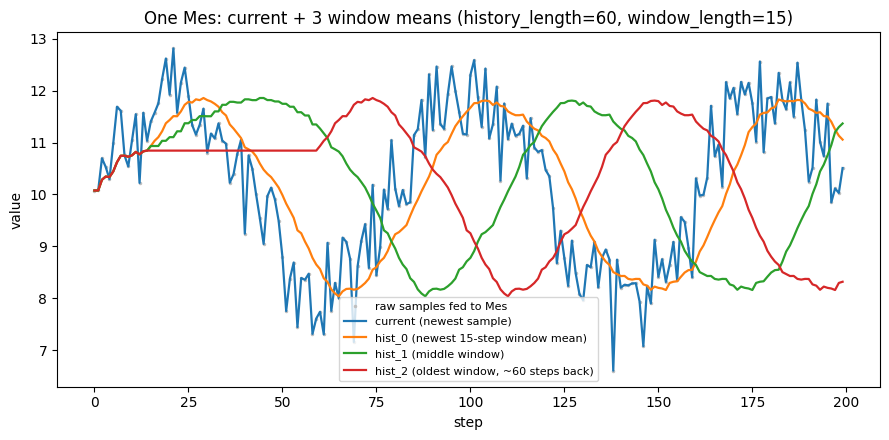

In [7]:
from WindGym.core import Mes

mes = Mes(current=True, rolling_mean=True, history_N=3,
          history_length=60, window_length=15)

rng = np.random.default_rng(0)
n_steps = 200
t = np.arange(n_steps)
raw = 10 + 2 * np.sin(2 * np.pi * t / 80) + rng.normal(0, 0.6, n_steps)

reported = np.zeros((n_steps, 4))  # current, hist_0, hist_1, hist_2
for k in range(n_steps):
    mes.add_measurement(raw[k])
    reported[k] = mes.get_measurements()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t, raw, ".", color="0.75", ms=3, label="raw samples fed to Mes")
labels = [
    "current (newest sample)",
    "hist_0 (newest 15-step window mean)",
    "hist_1 (middle window)",
    "hist_2 (oldest window, ~60 steps back)",
]
for j, lab in enumerate(labels):
    ax.plot(t, reported[:, j], lw=1.6, label=lab)
ax.set(xlabel="step", ylabel="value",
       title="One Mes: current + 3 window means (history_length=60, window_length=15)")
ax.legend(fontsize=8)
fig.tight_layout()


### Why observations are already "warm" at reset

`reset()` does not hand you empty buffers: after initializing the flow it runs a measurement pre-fill loop of `steps_on_reset` env steps (with no agent action) that pushes measurements into every `Mes`:

- `fill_window=True` (the default): pre-fill for the longest configured history, so every window mean is fully populated from step 0.
- `fill_window=False` (what `make_env` uses, for speed): a single pre-step. Each buffer then holds exactly one entry, so *every* reported value — current and all window means — equals that one sample. That is why the `hist_*` rows in the Part-3 decode were identical to `current`.
- `fill_window=<int>`: pre-fill exactly that many steps.

The next cell uses `fill_window=True` and then makes the flow actually change: it flips the upstream turbine's yaw target back and forth (wake steering) and decodes the downstream turbine's `ws_current` vs `ws_hist_0` at every step. Even on the steady-state pywake backend the downstream wind speed responds, and the 5-step window mean visibly lags the instantaneous value.


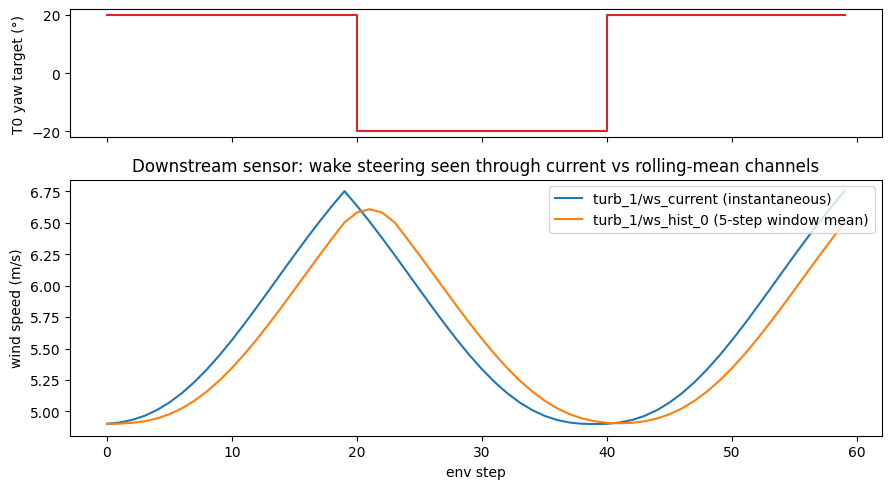

In [8]:
env_hist = make_env(BASE_CFG, fill_window=True, n_passthrough=5)
obs_h, _ = env_hist.reset(seed=0)
mm_hist = MeasurementManager(env_hist)

spec_by_name = {s.name: s for s in mm_hist.specs}
spec_ws = spec_by_name["turb_1/ws_current"]
i_cur = spec_ws.index_range[0]
i_h0 = spec_by_name["turb_1/ws_hist_0"].index_range[0]

log = {"cur": [], "h0": [], "yaw_cmd": []}
for k in range(60):
    # ActionMethod "wind": the action is a target yaw offset, scaled by the
    # config's yaw bounds (here ±30°). Square wave on the upstream turbine;
    # the yaw itself slews at yaw_step_sim (1°/step) toward the target.
    target_deg = 20.0 if (k // 20) % 2 == 0 else -20.0
    action = np.array([target_deg / 30.0, 0.0], dtype=np.float32)
    obs_h, _, terminated, truncated, _ = env_hist.step(action)
    if terminated or truncated:
        break
    log["cur"].append(unscale(obs_h[i_cur], spec_ws.min_val, spec_ws.max_val))
    log["h0"].append(unscale(obs_h[i_h0], spec_ws.min_val, spec_ws.max_val))
    log["yaw_cmd"].append(target_deg)

# Close before plotting: env.close() calls plt.close("all") via the renderer,
# which would also discard the figure we are about to draw.
env_hist.close()

steps = np.arange(len(log["cur"]))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True,
                               height_ratios=[1, 2])
ax1.step(steps, log["yaw_cmd"], where="post", color="tab:red")
ax1.set_ylabel("T0 yaw target (°)")
ax2.plot(steps, log["cur"], label="turb_1/ws_current (instantaneous)")
ax2.plot(steps, log["h0"], label="turb_1/ws_hist_0 (5-step window mean)")
ax2.set(xlabel="env step", ylabel="wind speed (m/s)",
        title="Downstream sensor: wake steering seen through current vs rolling-mean channels")
ax2.legend()
fig.tight_layout()


## 5. The multi-agent view (`WindFarmEnvMulti`)

`WindFarmEnvMulti` (PettingZoo parallel API, one agent per turbine) reuses exactly the same `FarmMes` machinery — the only difference is slicing. Each agent observes:

```text
[ its own turbine block | the shared farm block ]
```

so the per-agent observation size is `per_turbine + farm_block` from the Part-2 formula, and everything above about ordering, scaling, and history applies within each agent's vector. The farm block is literally the same numbers for every agent — a shared global signal (channel order ws, wd, TI, power, as before).


In [9]:
from WindGym import WindFarmEnvMulti

MULTI_CFG = copy.deepcopy(BASE_CFG)
MULTI_CFG["mes_level"]["farm_wd"] = True
MULTI_CFG["ws_mes"]["ws_rolling_mean"] = False  # current-only everywhere

menv = WindFarmEnvMulti(
    turbine=V80(),
    x_pos=np.arange(3) * 5.0 * V80().diameter(),
    y_pos=np.zeros(3),
    config=MULTI_CFG,
    backend="pywake",
    turbtype="None",
    n_passthrough=1,
    fill_window=False,
)

print("agents:", menv.possible_agents)
for a in menv.possible_agents:
    print(f"  {a}: obs {menv.observation_space(a).shape}, act {menv.action_space(a).shape}")

obs_multi, infos = menv.reset(seed=0)

# Per-agent layout: [ws_current, wd_current, yaw_current | farm ws_current, farm wd_current]
print("\nper-agent observations (scaled):")
for a, o in obs_multi.items():
    print(f"  {a}: {np.array2string(o, precision=3)}")

farm_slots = np.array([o[3:5] for o in obs_multi.values()])
assert np.allclose(farm_slots, farm_slots[0]), "farm block should be identical across agents"
print("\nfarm block (last 2 slots) is identical for every agent")

for _ in range(3):
    actions = {a: menv.action_space(a).sample() for a in menv.agents}
    obs_multi, rewards, terms, truncs, infos = menv.step(actions)
print("3 random steps OK; rewards:", {a: round(float(r), 3) for a, r in rewards.items()})
menv.close()


agents: ['turbine_0', 'turbine_1', 'turbine_2']
  turbine_0: obs (5,), act (1,)
  turbine_1: obs (5,), act (1,)
  turbine_2: obs (5,), act (1,)

per-agent observations (scaled):
  turbine_0: [-0.333  0.5    0.    -0.55   0.5  ]
  turbine_1: [-0.673  0.5    0.    -0.55   0.5  ]
  turbine_2: [-0.643  0.5    0.    -0.55   0.5  ]

farm block (last 2 slots) is identical for every agent
3 random steps OK; rewards: {'turbine_0': 0.419, 'turbine_1': 0.419, 'turbine_2': 0.419}


## 6. Cheat sheet

**Size formula**

```text
size(channel) = current + rolling_mean * history_N
per_turbine   = turb_ws*size(ws) + turb_wd*size(wd) + size(yaw) + turb_TI + turb_power*size(power)
total         = n_turb * per_turbine
                + farm_ws*size(ws) + farm_wd*size(wd) + farm_TI + farm_power*size(power)
```

**Layout** — turbine blocks first (T0, T1, …), farm block last. Per turbine: probes, ws, wd, yaw, derate, TI, power. Per channel: current first, then `hist_0` (newest) → `hist_{N-1}` (oldest). Farm block: ws, wd, TI, power.

**Gotchas**

- Yaw is always observed per turbine — there is no `turb_yaw` switch.
- Yaw scaling bounds come from the config (`farm.yaw_min/max`); all other scaling bounds come from constructor kwargs. Keep both identical between training and deployment — mismatched bounds silently reinterpret every observation.
- `fill_window=False` gives a single pre-fill step at reset, so all history slots start equal to the current value; `fill_window=True` starts with fully populated windows.
- Wind direction uses circular means, so buffers straddling 0°/360° average correctly.
- `MeasurementManager` gives the authoritative index → name → physical-range map; it refuses probe-configured envs.

**Where to go next**

- *Example 1 Make environment* — the full dynamic (dynamiks) setup, loading the config from a YAML file.
- `Docs/docs/config.yaml` — a fully commented reference config.
- The *Noise and Uncertainty* docs and `examples/measurement_error/` — adding sensor noise on top of these observations via `MeasurementManager`.
